# Chapter 12 Lab: Evidence Matrices and Honest Benchmarking

**Runtime:** 2–3 minutes · **Difficulty:** intermediate · **Credentials:** none

A headline score is not evidence by itself. This notebook compares fictional experiment
cards by uncertainty, temporal validity, point-in-time discipline, and independent review.
It shows how a lower raw score can deserve stronger claims than a higher but weaker study.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/12_evidence_matrix_and_benchmarks.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/12_evidence_matrix_and_benchmarks.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

- build a minimum comparison record;
- visualize sampling uncertainty;
- separate empirical quality from evidence maturity;
- shrink noisy small-sample estimates; and
- license claims according to the strength of the evaluation.


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab import canonical_hash, seed_everything
from finllm_lab.metrics import bootstrap_interval
from finllm_lab.plotting import COLORS, finish, set_finance_theme

set_finance_theme()
seed_everything(1212)
evidence = pd.read_csv(ROOT / "data" / "evidence_matrix.csv")
evidence.head()


,experiment_id,system,task,sample_size,quality,ci_low,ci_high,temporal_split,point_in_time,independent_review,data_status
0,exp-000,Lexical baseline,sentiment,339,0.62738,0.57591,0.67885,False,False,True,illustrative evidence card
1,exp-001,Calibrated classifier,retrieval,924,0.70152,0.67201,0.73102,True,True,False,illustrative evidence card
2,exp-002,Hybrid retrieval,policy compliance,664,0.74791,0.71488,0.78094,True,True,False,illustrative evidence card
3,exp-003,Governed agent,sentiment,1280,0.78294,0.76035,0.80552,True,False,False,illustrative evidence card
4,exp-004,Lexical baseline,retrieval,1339,0.62099,0.59500,0.64697,False,True,False,illustrative evidence card


## 1. Add evidence maturity


In [3]:
evidence["maturity_score"] = evidence[
    ["temporal_split", "point_in_time", "independent_review"]
].astype(int).mean(axis=1)
evidence["interval_width"] = evidence["ci_high"] - evidence["ci_low"]
evidence["claim_tier"] = pd.cut(
    evidence["maturity_score"],
    bins=[-0.01, 0.01, 0.34, 0.67, 1.01],
    labels=["illustration", "preliminary", "comparative", "audited"],
)
evidence[
    [
        "experiment_id",
        "system",
        "task",
        "sample_size",
        "quality",
        "maturity_score",
        "claim_tier",
    ]
].head(10)


,experiment_id,system,task,sample_size,quality,maturity_score,claim_tier
0,exp-000,Lexical baseline,sentiment,339,0.62738,0.333333,preliminary
1,exp-001,Calibrated classifier,retrieval,924,0.70152,0.666667,comparative
2,exp-002,Hybrid retrieval,policy compliance,664,0.74791,0.666667,comparative
3,exp-003,Governed agent,sentiment,1280,0.78294,0.333333,preliminary
4,exp-004,Lexical baseline,retrieval,1339,0.62099,0.333333,preliminary
5,exp-005,Calibrated classifier,policy compliance,297,0.68855,1.000000,audited
6,exp-006,Hybrid retrieval,sentiment,571,0.72773,0.333333,preliminary
7,exp-007,Governed agent,retrieval,558,0.79912,0.666667,comparative
8,exp-008,Lexical baseline,policy compliance,858,0.65373,0.333333,preliminary
9,exp-009,Calibrated classifier,sentiment,991,0.65396,0.333333,preliminary


## 2. Raw ranking versus evidence-aware ranking

We use a small neutral prior to shrink noisier estimates and multiply by an evidence
factor. This is an illustrative score, not a universal formula.


In [4]:
prior_n = 100
prior_mean = 0.50
evidence["shrunk_quality"] = (
    evidence["sample_size"] * evidence["quality"] + prior_n * prior_mean
) / (evidence["sample_size"] + prior_n)
evidence["evidence_aware_score"] = evidence["shrunk_quality"] * (
    0.55 + 0.45 * evidence["maturity_score"]
)
raw_top = evidence.nlargest(5, "quality")[
    ["experiment_id", "system", "task", "quality", "claim_tier"]
].assign(ranking="raw quality")
aware_top = evidence.nlargest(5, "evidence_aware_score")[
    ["experiment_id", "system", "task", "quality", "claim_tier"]
].assign(ranking="evidence aware")
pd.concat([raw_top, aware_top], ignore_index=True)


,experiment_id,system,task,quality,claim_tier,ranking
0,exp-015,Governed agent,sentiment,0.81161,comparative,raw quality
1,exp-023,Governed agent,policy compliance,0.81071,comparative,raw quality
2,exp-019,Governed agent,retrieval,0.80529,comparative,raw quality
3,exp-027,Governed agent,sentiment,0.80328,preliminary,raw quality
4,exp-011,Governed agent,policy compliance,0.79926,comparative,raw quality
5,exp-010,Hybrid retrieval,retrieval,0.74770,audited,evidence aware
6,exp-025,Calibrated classifier,retrieval,0.72139,audited,evidence aware
7,exp-019,Governed agent,retrieval,0.80529,comparative,evidence aware
8,exp-015,Governed agent,sentiment,0.81161,comparative,evidence aware
9,exp-005,Calibrated classifier,policy compliance,0.68855,audited,evidence aware


## 3. Uncertainty belongs on the chart


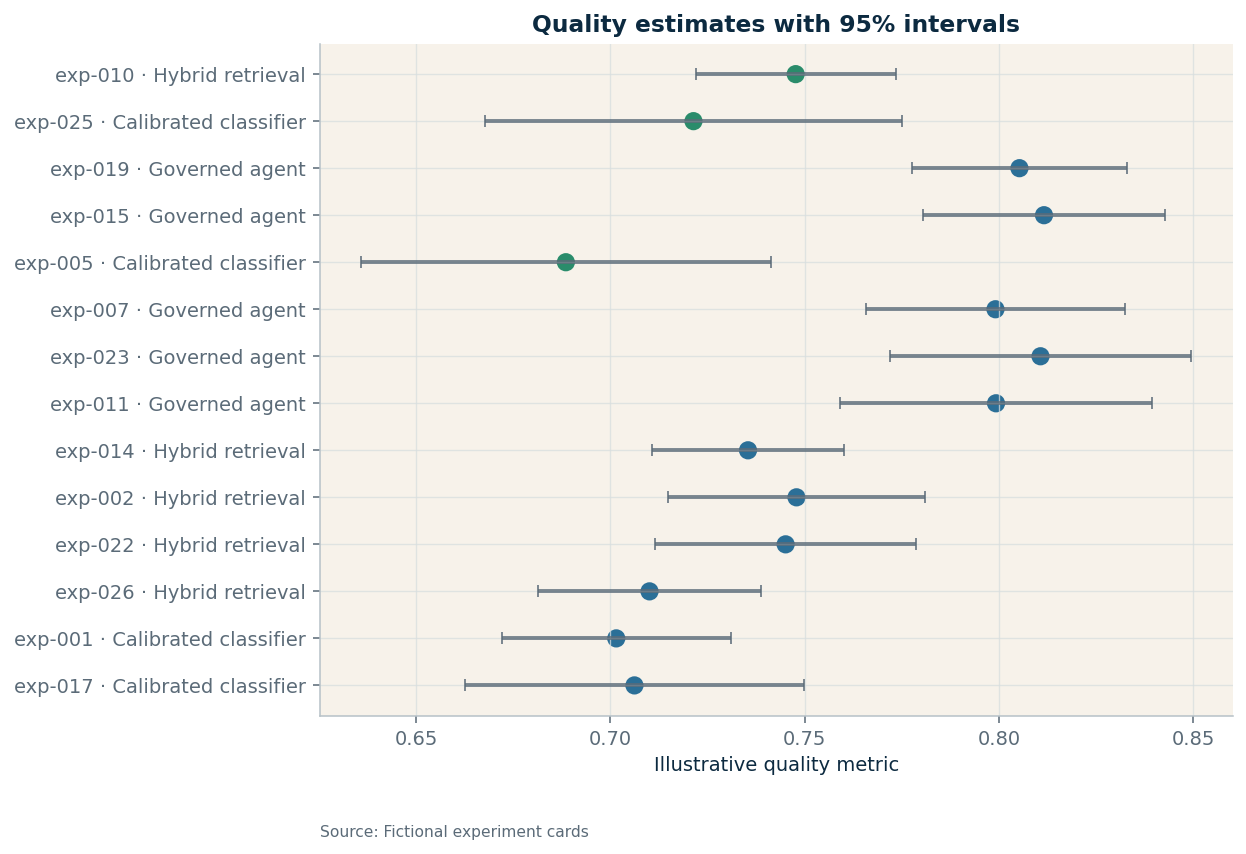

In [5]:
plot_frame = evidence.sort_values("evidence_aware_score").tail(14)
fig, ax = plt.subplots(figsize=(9, 6.2))
errors = np.vstack(
    [
        plot_frame["quality"] - plot_frame["ci_low"],
        plot_frame["ci_high"] - plot_frame["quality"],
    ]
)
colors = [
    {
        "illustration": COLORS["slate"],
        "preliminary": COLORS["gold"],
        "comparative": COLORS["blue"],
        "audited": COLORS["green"],
    }[str(tier)]
    for tier in plot_frame["claim_tier"]
]
ax.errorbar(
    plot_frame["quality"],
    np.arange(len(plot_frame)),
    xerr=errors,
    fmt="none",
    ecolor=COLORS["slate"],
    capsize=3,
    alpha=0.8,
)
ax.scatter(plot_frame["quality"], np.arange(len(plot_frame)), c=colors, s=70)
ax.set_yticks(np.arange(len(plot_frame)), plot_frame["experiment_id"] + " · " + plot_frame["system"])
ax.set(title="Quality estimates with 95% intervals", xlabel="Illustrative quality metric")
finish(ax, "Fictional experiment cards")
plt.tight_layout()


## 4. Validate the minimum comparison record


In [6]:
required_fields = {
    "experiment_id",
    "system",
    "task",
    "sample_size",
    "quality",
    "ci_low",
    "ci_high",
    "temporal_split",
    "point_in_time",
    "independent_review",
    "data_status",
}
record_check = pd.DataFrame(
    {
        "required_field": sorted(required_fields),
        "present": [field in evidence.columns for field in sorted(required_fields)],
        "non_null": [
            bool(evidence[field].notna().all()) if field in evidence.columns else False
            for field in sorted(required_fields)
        ],
    }
)
record_check


,required_field,present,non_null
0,ci_high,True,True
1,ci_low,True,True
2,data_status,True,True
3,experiment_id,True,True
4,independent_review,True,True
5,point_in_time,True,True
6,quality,True,True
7,sample_size,True,True
8,system,True,True
9,task,True,True


## 5. System-level uncertainty


In [7]:
system_intervals = []
for system, group in evidence.groupby("system"):
    estimate, low, high = bootstrap_interval(
        group["quality"], confidence=0.95, resamples=1500, seed=1212
    )
    system_intervals.append(
        {
            "system": system,
            "mean_quality": estimate,
            "ci_low": low,
            "ci_high": high,
            "experiments": len(group),
            "mean_maturity": group["maturity_score"].mean(),
        }
    )
system_intervals = pd.DataFrame(system_intervals).sort_values("mean_quality", ascending=False)
system_intervals.round(4)


,system,mean_quality,ci_low,ci_high,experiments,mean_maturity
1,Governed agent,0.8017,0.7945,0.8078,7,0.5714
2,Hybrid retrieval,0.7345,0.7252,0.7428,7,0.6190
0,Calibrated classifier,0.6974,0.6822,0.7114,7,0.6667
3,Lexical baseline,0.6391,0.6210,0.6557,7,0.2857


## 6. License the claim, not just the score


In [8]:
claim_policy = pd.DataFrame(
    [
        ("illustration", "The workflow runs on a fictional example.", "No performance claim."),
        ("preliminary", "The system shows promise on this sample.", "No generalization claim."),
        ("comparative", "The system outperformed the declared baseline under this protocol.", "Protocol-specific claim."),
        ("audited", "The result reproduced under point-in-time, independently reviewed evaluation.", "Still bounded to the tested domain."),
    ],
    columns=["tier", "licensed_statement", "boundary"],
)
claim_policy


,tier,licensed_statement,boundary
0,illustration,The workflow runs on a fictional example.,No performance claim.
1,preliminary,The system shows promise on this sample.,No generalization claim.
2,comparative,The system outperformed the declared baseline under this protocol.,Protocol-specific claim.
3,audited,"The result reproduced under point-in-time, independently reviewed evaluation.",Still bounded to the tested domain.


## 7. Reproducibility record


In [9]:
registry = {
    "dataset": "fictional evidence cards",
    "experiments": evidence["experiment_id"].tolist(),
    "required_fields_pass": bool(
        record_check[["present", "non_null"]].to_numpy().all()
    ),
    "ranking_rule": "shrunk_quality * (0.55 + 0.45 * maturity_score)",
    "top_evidence_aware": aware_top.iloc[0]["experiment_id"],
}
registry["fingerprint"] = canonical_hash(registry)
registry


{'dataset': 'fictional evidence cards',
 'experiments': ['exp-000',
                 'exp-001',
                 'exp-002',
                 'exp-003',
                 'exp-004',
                 'exp-005',
                 'exp-006',
                 'exp-007',
                 'exp-008',
                 'exp-009',
                 'exp-010',
                 'exp-011',
                 'exp-012',
                 'exp-013',
                 'exp-014',
                 'exp-015',
                 'exp-016',
                 'exp-017',
                 'exp-018',
                 'exp-019',
                 'exp-020',
                 'exp-021',
                 'exp-022',
                 'exp-023',
                 'exp-024',
                 'exp-025',
                 'exp-026',
                 'exp-027'],
 'fingerprint': '0468a3fe7f7529753b4f10d91a8cd87e0e8a1cd127eb4cb0dc14e3f578ff467e',
 'ranking_rule': 'shrunk_quality * (0.55 + 0.45 * maturity_score)',
 'required_fields_pass'

## Takeaways

- Sample size and uncertainty change how close scores should be interpreted.
- Random-split or non-point-in-time results cannot license deployment claims.
- Evidence maturity and task performance are distinct dimensions.
- A comparison record should be machine-readable and complete before ranking.

**Challenge:** replace the illustrative evidence score with a preregistered multi-criteria
decision rule and run a sensitivity analysis over its weights.
